In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split,  GridSearchCV, KFold
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import cohen_kappa_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

gpu_devices = tf.config.experimental.list_physical_devices('GPU')
for device in gpu_devices:
    tf.config.experimental.set_memory_growth(device, True)
from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
gpu_devices

[]

In [26]:
def get_pred_report(y_test, y_pred):
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Accuracy Score: ", accuracy_score(y_test, y_pred))
    print("Cohen Kappa Score: ", cohen_kappa_score(y_test, y_pred))
    print("F1 Score: ", f1_score(y_test, y_pred))

In [27]:
df = pd.read_csv('features.csv')
X = df.drop('target', axis=1)
y = df['target']

In [28]:
X.head(2)

,max_val,min_val,amplitude,mean,variance,skewness,kurt,shannon,sampen,apen,H,mmd,delta,theta,alpha,beta,gamma
0,21883.619214,364.541533,21519.077681,19934.809549,2.071895e+06,-11.290653,134.618195,0.105941,0.009542,0.020266,0.618476,22452.291968,21433.40,322.10,60.67,49.94,5906.14
1,19925.770273,17828.267821,2097.502452,18188.240056,2.497752e+05,2.131057,3.678422,1.306199,0.072748,0.082398,0.851989,2613.595689,82935.89,2196.35,483.98,275.79,24373.98


In [29]:
print(X.describe())

            max_val       min_val     amplitude          mean      variance  \
count  2.617550e+05  2.617550e+05  2.617550e+05  2.617550e+05  2.617550e+05   
mean  -3.378160e+04 -4.237905e+04  8.597448e+03 -3.816924e+04  1.076008e+09   
std    4.269743e+05  4.345740e+05  1.126991e+05  4.271447e+05  4.584513e+10   
min   -4.011350e+06 -5.028805e+06  2.230983e-06 -4.014417e+06  1.886810e-14   
25%    4.602391e+03  3.926133e+03  8.149281e+01  4.263857e+03  3.387989e+02   
50%    2.070000e+04  1.955566e+04  2.095695e+02  2.016109e+04  2.473825e+03   
75%    4.472638e+04  4.386159e+04  7.214055e+02  4.424386e+04  3.571326e+04   
max    4.449576e+06  2.440092e+06  9.205481e+06  3.352455e+06  8.199143e+12   

            skewness           kurt        shannon         sampen  \
count  261755.000000  261755.000000  261755.000000  261755.000000   
mean       -0.084297      -0.530234       2.092708       0.441224   
std         0.553021       1.665291       0.161015       0.277181   
min       -1

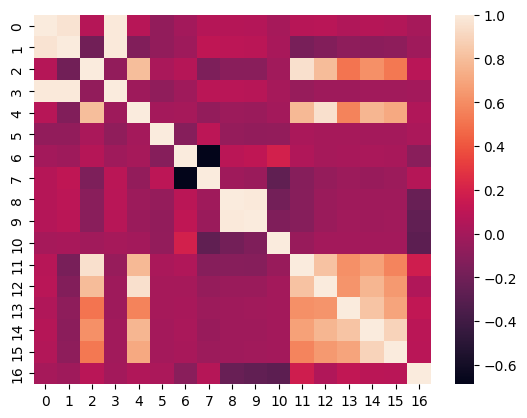

In [30]:
corr_matrix = np.corrcoef(X, rowvar=False)
sns.heatmap(corr_matrix, annot=False)
plt.show()

## Im going to check how many dimension are unused

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
print("Explaned Variance: ", explained_variance)

Explaned Variance:  [3.17585137e-01 1.77141761e-01 1.26577611e-01 1.08797363e-01
 6.59658749e-02 5.66356017e-02 5.09519800e-02 3.28321703e-02
 2.29162062e-02 1.73993719e-02 1.43859642e-02 4.16305360e-03
 2.88207709e-03 1.09348495e-03 5.70575461e-04 1.01767146e-04
 0.00000000e+00]


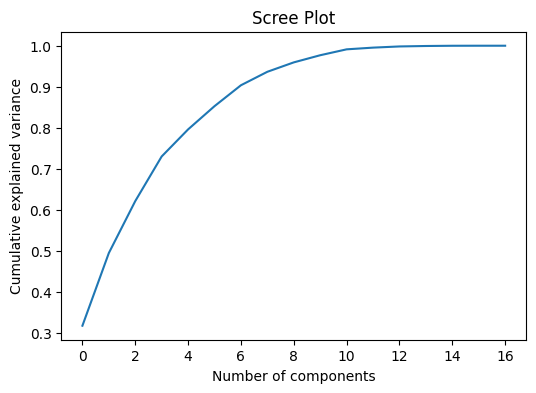

In [32]:
# Scree plot to visualize variance captured by principal components
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Scree Plot")
plt.show()

In [33]:
corr_df = pd.DataFrame(corr_matrix, columns=X.columns, index=X.columns)
threshold = 0.9
high_corr_pairs = [(col1, col2) for col1 in corr_df.columns for col2 in corr_df.columns 
                   if col1 != col2 and abs(corr_df.loc[col1, col2]) > threshold]

unique_high_corr_pairs = set(tuple(sorted(pair)) for pair in high_corr_pairs)
for pair in unique_high_corr_pairs:
    print(pair)
    
X = X.drop(['max_val', 'min_val', 'sampen', 'amplitude'], axis=1)

('mean', 'min_val')
('apen', 'sampen')
('max_val', 'min_val')
('amplitude', 'mmd')
('delta', 'variance')
('max_val', 'mean')


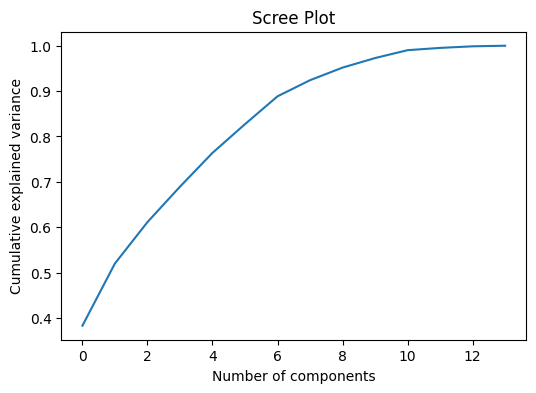

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_
plt.figure(figsize=(6, 4))
plt.plot(np.cumsum(explained_variance))
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Scree Plot")
plt.show()

<Axes: xlabel='amplitude', ylabel='target'>

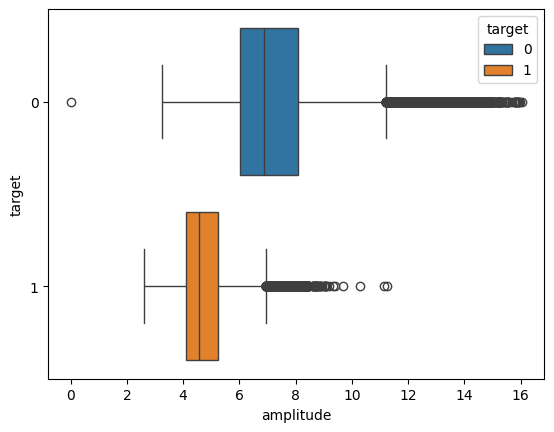

In [35]:
sns.boxplot(orient='h', y = y, x = np.abs(np.log(1+ X['amplitude'])), hue=y)

Text(0.5, 1.0, 'Scatter plot of amplitude vs mean')

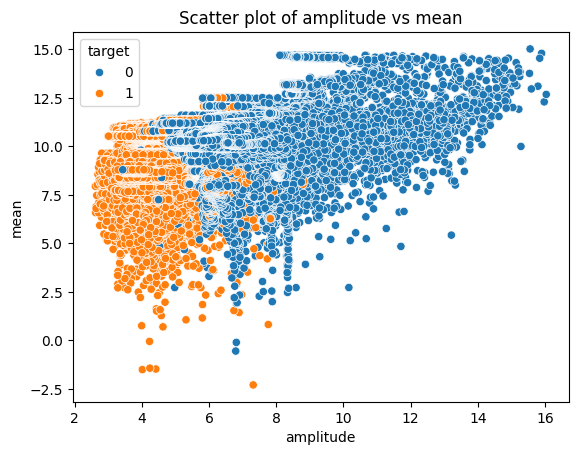

In [36]:
# Ensure there are no non-positive values before applying the log function
valid_indices = (X['mean'] > -1)
sns.scatterplot(x=np.abs(np.log(1 + X.loc[valid_indices, 'amplitude'])), y=np.log(X.loc[valid_indices, 'mean'] + 1), hue=y[valid_indices])
plt.title("Scatter plot of amplitude vs mean")

# Using logistique regression

In [63]:
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegressionCV(
    cv=5, max_iter=100,
    penalty='elasticnet', solver='saga',
    l1_ratios=[0.1],
    random_state=42,
    #Cs = [0.1],
    tol=1e-3  # Increased tolerance to avoid underflow
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
get_pred_report(y_test, y_pred)

c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did no

Confusion Matrix:
[[13351  7731]
 [ 3916 27353]]
Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.63      0.70     21082
           1       0.78      0.87      0.82     31269

    accuracy                           0.78     52351
   macro avg       0.78      0.75      0.76     52351
weighted avg       0.78      0.78      0.77     52351

Accuracy Score:  0.7775209642604726
Cohen Kappa Score:  0.523484006091828
F1 Score:  0.8244691272436815


c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [65]:
model.coef_

array([[-5.28161108e+00,  4.64269914e-01,  1.07823543e-02,
         9.21338794e-02,  3.81852260e-02,  3.86234269e-01,
         9.19301752e-02,  9.91372910e-01, -7.12164844e+00,
         1.23735376e-02,  7.23640156e-03,  8.02419045e-03,
         5.42121686e-03, -2.45893315e+00]])

In [56]:
from sklearn.feature_selection import RFE
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
selector = RFE(LogisticRegression(solver='saga', penalty="elasticnet", l1_ratio=0.2 , random_state=42), n_features_to_select=13)
selector = selector.fit(X_train, y_train)
selected_features = selector.support_

c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [66]:
X.columns

Index(['amplitude', 'mean', 'variance', 'skewness', 'kurt', 'shannon', 'apen',
       'H', 'mmd', 'delta', 'theta', 'alpha', 'beta', 'gamma'],
      dtype='object')

In [58]:
complement_selected_features = ~selected_features
X.columns[~selected_features]

Index(['theta'], dtype='object')

In [14]:
""" model = LogisticRegression(
    penalty='l1',
    max_iter=100,
    solver='liblinear',
    C=0.1,
    random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
get_pred_report(y_test, y_pred) """


" model = LogisticRegression(\n    penalty='l1',\n    max_iter=100,\n    solver='liblinear',\n    C=0.1,\n    random_state=42\n)\nmodel.fit(X_train, y_train)\ny_pred = model.predict(X_test)\nget_pred_report(y_test, y_pred) "

## SVM

### Linear

In [ ]:
""" linear_svm = SVC(kernel='linear', C=0.1, random_state=42)
linear_svm.fit(X_train, y_train)
y_pred = linear_svm.predict(X_test)
get_pred_report(y_test, y_pred) """

### Polynomial

In [ ]:
""" poly_svm = SVC(kernel='poly', degree=3, C=0.1, random_state=42)
poly_svm.fit(X_train, y_train)
y_pred = poly_svm.predict(X_test)
get_pred_report(y_test, y_pred) """

### RBF

In [ ]:
""" rbf_svm = SVC(kernel='rbf', C=0.1, random_state=42)
rbf_svm.fit(X_train, y_train)
y_pred = rbf_svm.predict(X_test)
get_pred_report(y_test, y_pred) """

# Random Forest

In [14]:
rf_classifier = RandomForestClassifier(n_estimators=5, criterion="entropy", max_depth=4, random_state=0)
rf_classifier.fit(X_train, y_train)
y_pred = rf_classifier.predict(X_test)
get_pred_report(y_test, y_pred)

Confusion Matrix:
[[18640  2442]
 [ 4026 27243]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85     21082
           1       0.92      0.87      0.89     31269

    accuracy                           0.88     52351
   macro avg       0.87      0.88      0.87     52351
weighted avg       0.88      0.88      0.88     52351

Accuracy Score:  0.8764493514928081
Cohen Kappa Score:  0.7462791644041646
F1 Score:  0.8938871936214194


# KNN

In [67]:
knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
get_pred_report(y_test, y_pred)

Confusion Matrix:
[[15649  5433]
 [ 4292 26977]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76     21082
           1       0.83      0.86      0.85     31269

    accuracy                           0.81     52351
   macro avg       0.81      0.80      0.81     52351
weighted avg       0.81      0.81      0.81     52351

Accuracy Score:  0.8142346851063017
Cohen Kappa Score:  0.610412913969161
F1 Score:  0.8472808932301072


# Naive Bayes

In [16]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)
get_pred_report(y_test, y_pred)

Confusion Matrix:
[[ 8585 12497]
 [   92 31177]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.41      0.58     21082
           1       0.71      1.00      0.83     31269

    accuracy                           0.76     52351
   macro avg       0.85      0.70      0.70     52351
weighted avg       0.82      0.76      0.73     52351

Accuracy Score:  0.7595270386430059
Cohen Kappa Score:  0.44713459069181394
F1 Score:  0.8320190011075084


# XGboost

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(X.columns))
dtest = xgb.DMatrix(X_test, label=y_test, feature_names=list(X.columns))

# Set parameters for XGBoost
params = {
    'max_depth': 3,
    'eta': 0.1,
    'objective': 'binary:logistic'
}

# Perform cross-validation
cv_results = xgb.cv(
    params,
    dtrain,
    num_boost_round=100,
    nfold=2,
    metrics={'error'},
    as_pandas=True,
    seed=42
)

# Print cross-validation results
print(cv_results)

# Train the model using the best number of boosting rounds from cross-validation
best_num_boost_round = cv_results['test-error-mean'].idxmin()
bst = xgb.train(params, dtrain, num_boost_round=best_num_boost_round)

# Make predictions
preds = bst.predict(dtest)
y_pred = [round(value) for value in preds]
get_pred_report(y_test, y_pred)

    train-error-mean  train-error-std  test-error-mean  test-error-std
0           0.402151         0.000019         0.402151        0.000019
1           0.172938         0.000879         0.173125        0.001514
2           0.111645         0.022278         0.112104        0.022879
3           0.087295         0.000468         0.088079        0.000019
4           0.084650         0.000707         0.085118        0.000010
..               ...              ...              ...             ...
95          0.055066         0.000664         0.056398        0.000726
96          0.055047         0.000664         0.056384        0.000731
97          0.054798         0.000635         0.056193        0.000903
98          0.054703         0.000683         0.056150        0.000898
99          0.054603         0.000735         0.056040        0.000864

[100 rows x 4 columns]
Confusion Matrix:
[[19775  1307]
 [ 1611 29658]]
Classification Report:
              precision    recall  f1-score   suppor

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

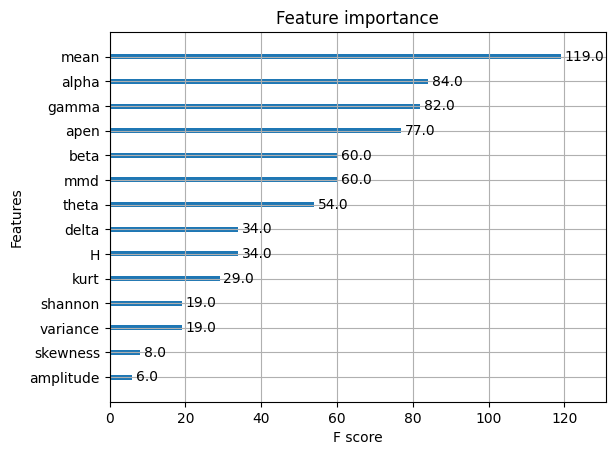

In [55]:
xgb.plot_importance(bst)

# Neural Network

In [47]:
input_size = X_train.shape[1]

def create_model(input_size):
    model = Sequential()
    model.add(Input(shape=(input_size,)))  # Use Input layer here directly
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Perform k-fold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cvscores = []

""" X_test_fold = X_test.reset_index(drop=True)
X_train_fold = X_train.reset_index(drop=True)
y_train_fold = y_train.reset_index(drop=True)
y_test_fold = y_test.reset_index(drop=True) """

X_test_fold = X_test
X_train_fold = X_train
y_train_fold = y_train
y_test_fold = y_test


for train, test in kfold.split(X_train_fold, y_train_fold):
    # Convert indices to integer arrays
    train_idx = train.astype(int)
    test_idx = test.astype(int)
    
    # Create model
    model = create_model(input_size)

    # Fit the model
    model.fit(X_train_fold.iloc[train_idx], y_train_fold.iloc[train_idx], epochs=9, batch_size=32, verbose=0)
    
    # Evaluate the model
    scores = model.evaluate(X_train_fold.iloc[test_idx], y_train_fold.iloc[test_idx], verbose=0)
    print(f"Accuracy: {scores[1] * 100:.2f}%")
    cvscores.append(scores[1] * 100)

# Print the mean and standard deviation of the accuracy
print(f"Mean Accuracy: {np.mean(cvscores):.2f}%")
print(f"Standard Deviation: {np.std(cvscores):.2f}%")

Accuracy: 76.63%
Accuracy: 59.76%
Accuracy: 77.02%
Accuracy: 59.76%
Accuracy: 60.13%
Mean Accuracy: 66.66%
Standard Deviation: 8.30%


In [50]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
get_pred_report(y_test, y_pred)

1636/1636 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step
Confusion Matrix:
[[    0 21082]
 [    0 31269]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     21082
           1       0.60      1.00      0.75     31269

    accuracy                           0.60     52351
   macro avg       0.30      0.50      0.37     52351
weighted avg       0.36      0.60      0.45     52351

Accuracy Score:  0.5972951806078203
Cohen Kappa Score:  0.0
F1 Score:  0.7478832815116001


c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is il

# Merging the models

In [19]:
from sklearn.ensemble import StackingClassifier
from scikeras.wrappers import KerasClassifier

In [20]:
""" def create_nn_model():
    input_size = X_train.shape[1]
    model = Sequential([
        model.add(Input(shape=(input_size,))),
        Dense(32, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model """

# Wrapping neural network with KerasClassifier for compatibility
# nn_model = KerasClassifier(build_fn=create_nn_model, epochs=8, batch_size=64, verbose=0)

# Define base learners
base_learners = [
    ('xgb', xgb.XGBClassifier(max_depth=3 ,use_label_encoder=False, eval_metric='logloss', random_state=42)),
    #('nn', nn_model),
    ('lr', LogisticRegression(max_iter=200)),
    ('nb', GaussianNB()),
    ('knn', KNeighborsClassifier(n_neighbors=4)),
    ('rf', RandomForestClassifier(n_estimators=4, max_depth=4, random_state=42))
]

# Create a stacking ensemble with logistic regression as the meta-learner
stacking_ensemble = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression()
)

# Train ensemble
stacking_ensemble.fit(X_train, y_train)

# Evaluate ensemble
y_pred = stacking_ensemble.predict(X_test)
print("Ensemble accuracy:", accuracy_score(y_test, y_pred))
get_pred_report(y_test, y_pred)

c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:46:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Marti\OneDrive - CentraleSupelec\CS courses\S9\ML\Competition\EEG_signals_quality_analysis\Env\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\

Ensemble accuracy: 0.9565051288418559
Confusion Matrix:
[[19927  1155]
 [ 1122 30147]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     21082
           1       0.96      0.96      0.96     31269

    accuracy                           0.96     52351
   macro avg       0.95      0.95      0.95     52351
weighted avg       0.96      0.96      0.96     52351

Accuracy Score:  0.9565051288418559
Cohen Kappa Score:  0.9095636625920851
F1 Score:  0.9636093397899985


# FINAL TEST

In [21]:
from os.path import join
import os
import numpy as np
import pandas as pd
import utils
ROOT_TEST_PATH = join("..","Data","test")
test_data = {i:np.load(join(ROOT_TEST_PATH, f"data_{i}.npy")) for i in [4,5]}
# We process each record independantly


In [22]:
test_channels = [4,5]
test_data = None
for test_channel in test_channels:
    if os.path.exists(join(f"test_features.csv")):
        df_test = pd.read_csv(join(f"test_features.csv"))
    else:
        test_data = {i:np.load(join(ROOT_TEST_PATH, f"data_{i}.npy")) for i in [4,5]}
        break

In [30]:
if test_data is not None:
    df_list = []
    for record_number, data in test_data.items():
        data_filtered, data_raw = utils.process_data(data[:, :])
        for channel in range(data_filtered.shape[0]):
            df_sub_features = utils.compute_features_on_record(data_raw[channel], data_filtered[channel])
            df_sub_features['channel'] = channel
            df_sub_features['record_number'] = record_number
            df_list.append(df_sub_features)
            print(f"Record {record_number} Channel {channel} processed")
    
    df = pd.concat(df_list, ignore_index=True, axis=0)
    df.to_csv("test_features.csv", index=False)
    df_test = df

In [31]:
X_test = df_test.drop(['record_number', 'channel'], axis=1).copy()
X_test = X_test.drop(['max_val', 'min_val', 'sampen'], axis=1)

#y_pred = bst.predict(xgb.DMatrix(X_test))
y_pred = stacking_ensemble.predict(X_test)
y_pred = [round(value) for value in y_pred]

ValueError: feature_names mismatch: ['amplitude', 'mean', 'variance', 'skewness', 'kurt', 'shannon', 'apen', 'H', 'mmd', 'delta', 'theta', 'alpha', 'beta', 'gamma'] ['amplitude', 'mean', 'variance', 'skewness', 'kurt', 'shannon', 'apen', 'H', 'mmd', 'delta', 'theta', 'alpha', 'beta', 'gamma', 'target', 'count', 'identifier']
training data did not have the following fields: count, identifier, target

In [25]:
df_test['target'] = y_pred
df_test

,max_val,min_val,amplitude,mean,variance,skewness,kurt,shannon,sampen,apen,H,mmd,delta,theta,alpha,beta,gamma,channel,record_number,target
0,2.226419e+06,1.435899e+04,2.212060e+06,1.527910e+06,2.277460e+11,-0.029585,-0.968328,1.919367,0.012258,0.013674,0.510314,2.241697e+06,9.642844e+10,4.522714e+08,1.642967e+08,1.052463e+08,3.213043e+08,0,4,0
1,2.361446e+06,2.188614e+06,1.728319e+05,2.240012e+06,2.736788e+09,1.016287,-0.278344,1.955082,0.060353,0.158844,0.573494,3.938715e+05,2.792431e+09,9.461253e+07,1.054115e+07,1.756541e+06,2.207420e+08,0,4,0
2,2.211281e+06,2.180484e+06,3.079704e+04,2.188540e+06,4.768331e+07,1.159426,0.527373,1.908508,0.550493,0.564896,0.573674,4.596048e+04,1.720534e+07,1.447170e+05,6.793104e+04,6.689421e+04,2.581053e+08,0,4,0
3,2.186531e+06,2.180150e+06,6.380931e+03,2.182845e+06,2.493643e+06,0.064411,-0.984368,2.123442,0.463491,0.374095,0.113260,2.233601e+04,2.000890e+05,8.027660e+03,4.167900e+03,9.494170e+03,2.468760e+08,0,4,0
4,2.190798e+06,2.182265e+06,8.533214e+03,2.186321e+06,3.712825e+06,0.023412,-0.641316,2.192682,0.366459,0.305796,0.191000,2.355785e+04,6.724015e+05,1.724903e+04,1.241620e+04,2.378501e+04,2.451030e+08,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112610,2.550976e+03,1.709792e+03,8.411833e+02,2.152193e+03,4.486224e+04,-0.005575,-1.266849,2.194618,0.607630,0.558647,0.107357,3.543875e+03,1.473440e+03,2.516000e+02,1.057130e+03,4.868300e+02,5.043478e+06,4,5,0
112611,4.150086e+04,-1.770189e+04,5.920275e+04,3.188071e+03,1.039099e+08,1.956045,4.695835,1.339143,0.030504,0.088912,0.736281,8.814076e+04,1.108451e+08,4.855057e+06,2.430009e+05,9.275326e+04,7.889406e+06,4,5,0
112612,8.792119e+04,-1.786218e+04,1.057834e+05,-6.429804e+03,9.557952e+07,7.269039,58.772724,0.788885,0.043391,0.062427,0.500249,1.195248e+05,4.593963e+07,2.281776e+07,1.899503e+07,2.147406e+07,2.030817e+07,4,5,0
112613,-5.957452e+03,-9.243913e+03,3.286461e+03,-7.142185e+03,6.552636e+05,-1.307767,0.733690,1.929584,0.538850,0.532376,0.603584,6.151948e+03,3.282235e+05,5.329650e+03,1.089200e+03,8.009700e+02,1.726057e+06,4,5,0


## Format to output

In [26]:
df_test['count'] = df_test.groupby(['record_number', 'channel']).cumcount()

In [27]:
df_test['identifier'] = (df_test['record_number'] * 1e6 + (df_test['channel'] + 1) * 1e5 + df_test['count']).astype(int)


In [28]:
df_test.head()

,max_val,min_val,amplitude,mean,variance,skewness,kurt,shannon,sampen,apen,...,delta,theta,alpha,beta,gamma,channel,record_number,target,count,identifier
0,2.226419e+06,1.435899e+04,2.212060e+06,1.527910e+06,2.277460e+11,-0.029585,-0.968328,1.919367,0.012258,0.013674,...,9.642844e+10,4.522714e+08,1.642967e+08,1.052463e+08,3.213043e+08,0,4,0,0,4100000
1,2.361446e+06,2.188614e+06,1.728319e+05,2.240012e+06,2.736788e+09,1.016287,-0.278344,1.955082,0.060353,0.158844,...,2.792431e+09,9.461253e+07,1.054115e+07,1.756541e+06,2.207420e+08,0,4,0,1,4100001
2,2.211281e+06,2.180484e+06,3.079704e+04,2.188540e+06,4.768331e+07,1.159426,0.527373,1.908508,0.550493,0.564896,...,1.720534e+07,1.447170e+05,6.793104e+04,6.689421e+04,2.581053e+08,0,4,0,2,4100002
3,2.186531e+06,2.180150e+06,6.380931e+03,2.182845e+06,2.493643e+06,0.064411,-0.984368,2.123442,0.463491,0.374095,...,2.000890e+05,8.027660e+03,4.167900e+03,9.494170e+03,2.468760e+08,0,4,0,3,4100003
4,2.190798e+06,2.182265e+06,8.533214e+03,2.186321e+06,3.712825e+06,0.023412,-0.641316,2.192682,0.366459,0.305796,...,6.724015e+05,1.724903e+04,1.241620e+04,2.378501e+04,2.451030e+08,0,4,0,4,4100004


In [32]:
submission_df = df_test[["identifier", "target"]].copy()

In [33]:
submission_path = join("..", "Results", "submission_martin.csv")
submission_df.to_csv(submission_path, index=False)

# Ideas

utilizar diferentes modelos para los distintos channels.
Probar con menos feautures y ver si mejora el modelo con más features o no. probar si me da lo mismo que el professor usando su metodo.
